In [1]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount("/content/drive")

data = pd.read_csv("/content/drive/MyDrive/datasets/labeled_data.csv")

Mounted at /content/drive


In [2]:
data.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [3]:
data.info

<bound method DataFrame.info of        Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0               0      3            0                   0        3      2   
1               1      3            0                   3        0      1   
2               2      3            0                   3        0      1   
3               3      3            0                   2        1      1   
4               4      6            0                   6        0      1   
...           ...    ...          ...                 ...      ...    ...   
24778       25291      3            0                   2        1      1   
24779       25292      3            0                   1        2      2   
24780       25294      3            0                   3        0      1   
24781       25295      6            0                   6        0      1   
24782       25296      3            0                   0        3      2   

                                                   tweet  
0      !!! RT @mayasolovely: As a woman you shouldn't...  
1      !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2      !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3      !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4      !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  
...                                                  ...  
24778  you's a muthaf***in lie &#8220;@LifeAsKing: @2...  
24779  you've gone and broke the wrong heart baby, an...  
24780  young buck wanna eat!!.. dat nigguh like I ain...  
24781              youu got wild bitches tellin you lies  
24782  ~~Ruffled | Ntac Eileen Dahlia - Beautiful col...  

[24783 rows x 7 columns]>

In [4]:
data.describe

<bound method NDFrame.describe of        Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0               0      3            0                   0        3      2   
1               1      3            0                   3        0      1   
2               2      3            0                   3        0      1   
3               3      3            0                   2        1      1   
4               4      6            0                   6        0      1   
...           ...    ...          ...                 ...      ...    ...   
24778       25291      3            0                   2        1      1   
24779       25292      3            0                   1        2      2   
24780       25294      3            0                   3        0      1   
24781       25295      6            0                   6        0      1   
24782       25296      3            0                   0        3      2   

                                                   tweet  
0      !!! RT @mayasolovely: As a woman you shouldn't...  
1      !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2      !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3      !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4      !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  
...                                                  ...  
24778  you's a muthaf***in lie &#8220;@LifeAsKing: @2...  
24779  you've gone and broke the wrong heart baby, an...  
24780  young buck wanna eat!!.. dat nigguh like I ain...  
24781              youu got wild bitches tellin you lies  
24782  ~~Ruffled | Ntac Eileen Dahlia - Beautiful col...  

[24783 rows x 7 columns]>

In [5]:
data.nunique()

,0
Unnamed: 0,24783
count,5
hate_speech,8
offensive_language,10
neither,10
class,3
tweet,24783


In [6]:
data.columns

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [7]:
data_cleaned = data.drop(columns=['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither'])


data_cleaned.rename(columns={'class': 'label'}, inplace=True)

In [8]:
data_cleaned

,label,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...
24778,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,2,"you've gone and broke the wrong heart baby, an..."
24780,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,1,youu got wild bitches tellin you lies


In [9]:
data_cleaned['label'].value_counts()

,count
label,
1,19190
2,4163
0,1430


In [10]:
data_cleaned.isnull().sum()

,0
label,0
tweet,0


In [11]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove special characters, numbers and punctuation, but keep spaces
    text = re.sub(r'[^\w\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    # Join tokens back into a string
    return " ".join(filtered_tokens)

# Apply cleaning function to the tweet column
data_cleaned['tweet'] = data_cleaned['tweet'].apply(clean_text)

print("\nData after cleaning:")
data_cleaned.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Data after cleaning:


,label,tweet
0,2,rt woman shouldnt complain cleaning house amp ...
1,1,rt boy dats coldtyga dwn bad cuffin dat hoe 1s...
2,1,rt dawg rt ever fuck bitch start cry confused ...
3,1,rt look like tranny
4,1,rt shit hear might true might faker bitch told...


<Axes: xlabel='label', ylabel='count'>

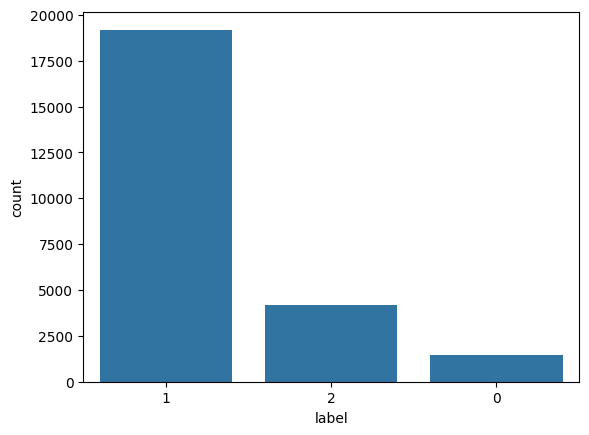

In [12]:
import seaborn as sns

sns.countplot(data=data_cleaned,x='label',order=data_cleaned['label'].value_counts().index)

In [13]:
from tqdm import tqdm

def preprocess_text(text_data):
    preprocessed_text = []

    for sentence in tqdm(text_data):
        sentence = re.sub(r'[^\w\s]', '', sentence)
        sentence = re.sub(r'\brt\b', '', sentence)

        preprocessed_text.append(' '.join(token.lower()
                                  for token in str(sentence).split()
                                  if token not in stopwords.words('english')))

    return preprocessed_text

In [14]:
preprocessed_review = preprocess_text(data_cleaned['tweet'].values)
data_cleaned['tweet'] = preprocessed_review

100%|██████████| 24783/24783 [00:13<00:00, 1805.37it/s]


In [15]:
data_cleaned

,label,tweet
0,2,woman shouldnt complain cleaning house amp man...
1,1,boy dats coldtyga dwn bad cuffin dat hoe 1st p...
2,1,dawg ever fuck bitch start cry confused shit
3,1,look like tranny
4,1,shit hear might true might faker bitch told ya...
...,...,...
24778,1,yous muthafin lie 8220 right tl trash 8230 min...
24779,2,youve gone broke wrong heart baby drove rednec...
24780,1,young buck wan na eat dat nigguh like aint fuc...
24781,1,youu got wild bitches tellin lies


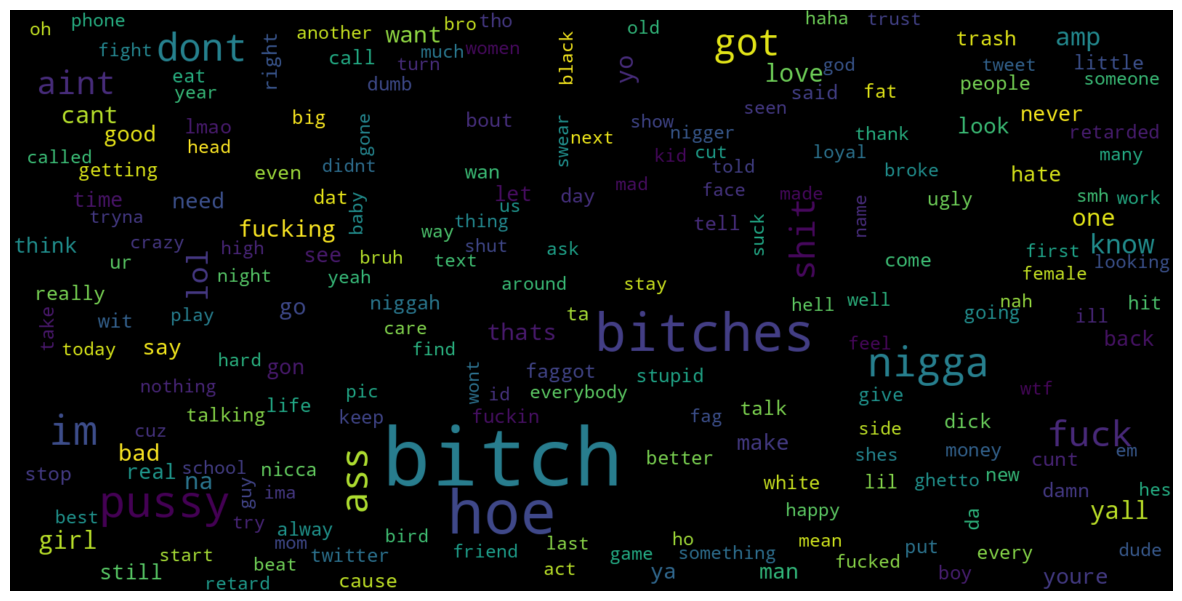

In [16]:
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

consolidated = ' '.join(word for word in data_cleaned['tweet'][data_cleaned['label'] == 1].astype(str))

wordCloud = WordCloud(width=1600,
                      height=800,
                      random_state=21,
                      max_font_size=110,
                      collocations=False)

plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()


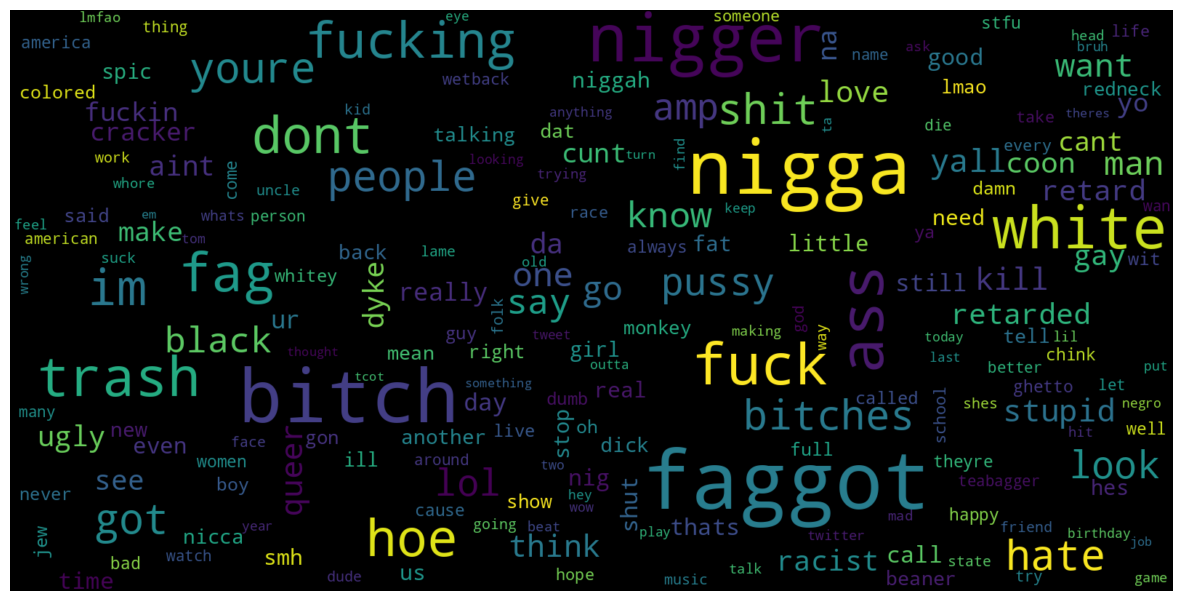

In [17]:
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

consolidated = ' '.join(word for word in data_cleaned['tweet'][data_cleaned['label'] == 0].astype(str))

wordCloud = WordCloud(width=1600,
                      height=800,
                      random_state=21,
                      max_font_size=110,
                      collocations=False)

plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()


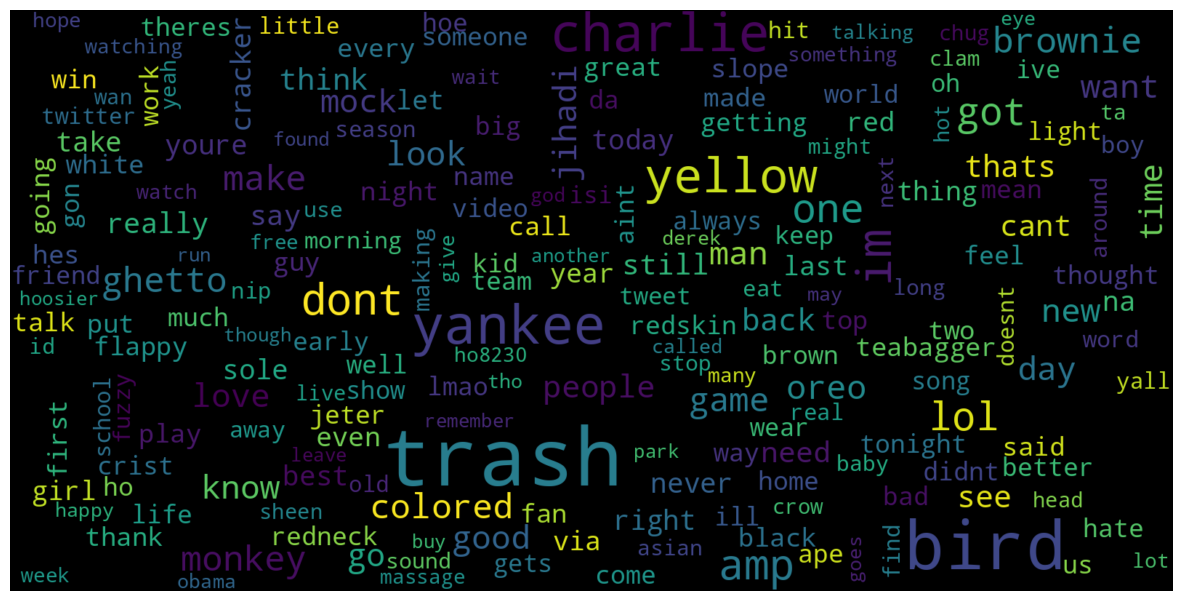

In [18]:
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

consolidated = ' '.join(word for word in data_cleaned['tweet'][data_cleaned['label'] == 2].astype(str))

wordCloud = WordCloud(width=1600,
                      height=800,
                      random_state=21,
                      max_font_size=110,
                      collocations=False)

plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()


<Axes: title={'center': 'Bar Chart of Top Words Frequency'}, xlabel='Top Words', ylabel='Count'>

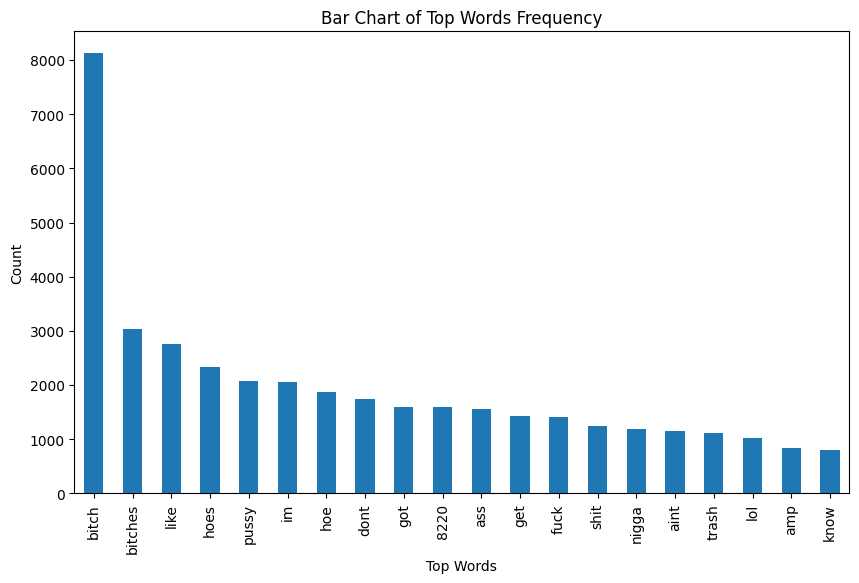

In [19]:
from sklearn.feature_extraction.text import CountVectorizer


def get_top_n_words(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1],reverse=True)
    return words_freq[:n]


common_words = get_top_n_words(data_cleaned['tweet'], 20)
df1 = pd.DataFrame(common_words, columns=['Review', 'count'])

df1.groupby('Review').sum()['count'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 6),
    xlabel="Top Words",
    ylabel="Count",
    title="Bar Chart of Top Words Frequency"
)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

x_train, x_test, y_train, y_test = train_test_split(data_cleaned['tweet'],data_cleaned['label'],test_size=0.25,stratify=data_cleaned['label'])

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
x_train_v = vectorization.fit_transform(x_train)
x_test_v = vectorization.transform(x_test)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_v, y_train)


print(f"Train Accuracy:{accuracy_score(y_train, model.predict(x_train_v))}")
print(f"Test Accuracy:{accuracy_score(y_test, model.predict(x_test_v))}")

Train Accuracy:0.9381826007424544
Test Accuracy:0.8970303421562298


In [23]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train_v, y_train)

print(f"Train Accuracy:{accuracy_score(y_train, model.predict(x_train_v))}")
print(f"Test Accuracy:{accuracy_score(y_test, model.predict(x_test_v))}")

Train Accuracy:0.9979555603378706
Test Accuracy:0.8808908973531311


In [24]:
import torch
from transformers import BertForSequenceClassification
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(x_train.tolist(), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(x_test.tolist(), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [25]:
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = TweetDataset(train_encodings, list(y_train))
val_dataset = TweetDataset(val_encodings, list(y_test))


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [30]:
from tqdm import tqdm

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 1162/1162 [03:10<00:00,  6.09it/s]


Epoch 1, Loss: 0.2830


100%|██████████| 1162/1162 [03:12<00:00,  6.04it/s]


Epoch 2, Loss: 0.2352


100%|██████████| 1162/1162 [03:12<00:00,  6.04it/s]

Epoch 3, Loss: 0.2052


In [31]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].size(0)

print("Validation Accuracy:", correct / total)


Validation Accuracy: 0.9030019367333764


### We could have probably achieved more accuracy by data augmentation techniques such as synoynm changing.

In [32]:
torch.save(model.state_dict(),"/content/drive/MyDrive/models/bert_model_hate_speech.pkl")